In [16]:
# ============================================================
# ЛАБОРАТОРНАЯ РАБОТА: EDA датасета Fish Market
# Формат вектора признаков: Species, Weight, Length1, Length2,
#                           Length3, Height, Width
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.width', 120)

RANDOM_STATE = 42

Шаг 2. Паспорт данных
Сформировать паспорт данных по единому шаблону из общих требований к практикуму. Для каждого поля явно указать:
• исходное имя столбца и его предметный смысл;
• тип данных и единицы измерения;
• назначение: признак, целевая переменная, группирующий признак, идентификатор или служебное поле;
• допустимость пропусков и предполагаемую причину их появления;
• диапазон допустимых значений и проверки физического смысла.


In [17]:
# Загрузка датасета Fish.csv (положить файл рядом с ноутбуком)
df = pd.read_csv('Fish.csv')

FEATURES = ['Species','Weight','Length1','Length2','Length3','Height','Width']
df = df[FEATURES].copy()

print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (158, 7)

Типы данных:
Species        str
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

Первые 5 строк:


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [18]:
print("Описательные статистики:")
df.describe(include='all').T

print("Численность по видам:")
print(df['Species'].value_counts())

Описательные статистики:
Численность по видам:
Species
Perch        56
Bream        35
Roach        19
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


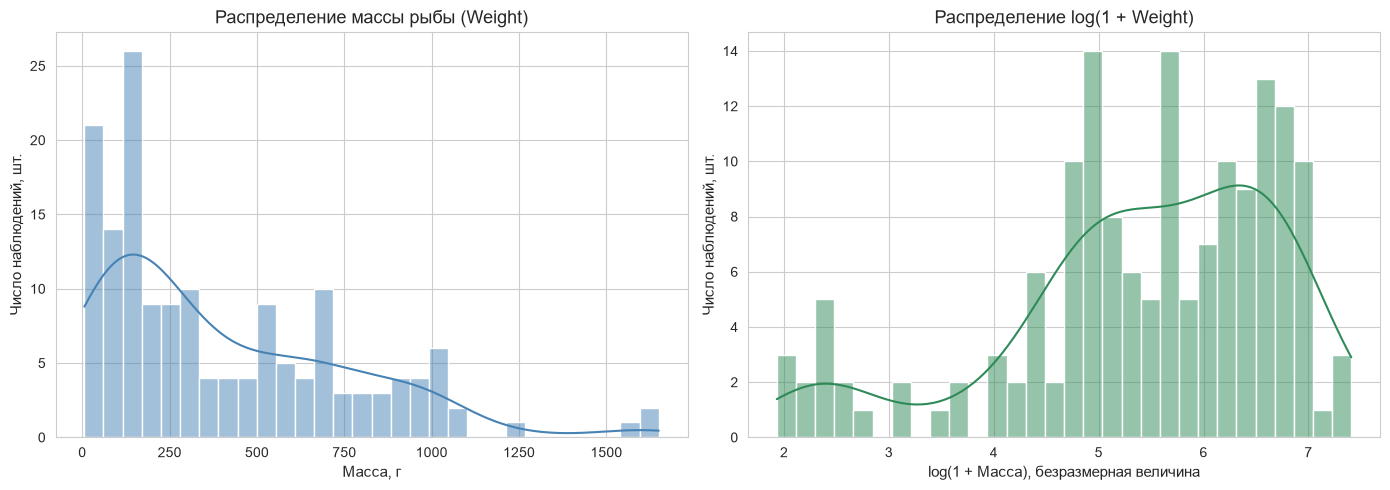

Асимметрия (skew), исходная шкала: 1.102
Асимметрия (skew), лог-шкала:      -0.977
Shapiro-Wilk p-value (исходная):   8.7713e-10
Shapiro-Wilk p-value (лог):        3.6668e-08


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычная шкала
sns.histplot(df['Weight'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение массы рыбы (Weight)')
axes[0].set_xlabel('Масса, г')
axes[0].set_ylabel('Число наблюдений, шт.')

# Логарифмическая шкала
sns.histplot(np.log1p(df['Weight']), kde=True, bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Распределение log(1 + Weight)')
axes[1].set_xlabel('log(1 + Масса), безразмерная величина')
axes[1].set_ylabel('Число наблюдений, шт.')

plt.tight_layout()
plt.show()

# Числовые характеристики асимметрии и нормальности
skew_raw = df['Weight'].skew()
skew_log = np.log1p(df['Weight']).skew()
shapiro_raw = stats.shapiro(df['Weight']).pvalue
shapiro_log = stats.shapiro(np.log1p(df['Weight'])).pvalue

print(f"Асимметрия (skew), исходная шкала: {skew_raw:.3f}")
print(f"Асимметрия (skew), лог-шкала:      {skew_log:.3f}")
print(f"Shapiro-Wilk p-value (исходная):   {shapiro_raw:.4e}")
print(f"Shapiro-Wilk p-value (лог):        {shapiro_log:.4e}")

C:\Users\Liza\AppData\Local\Temp\ipykernel_8308\4166498697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', ax=axes[0], palette='Set2', order=order)
C:\Users\Liza\AppData\Local\Temp\ipykernel_8308\4166498697.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y='Weight', ax=axes[1],


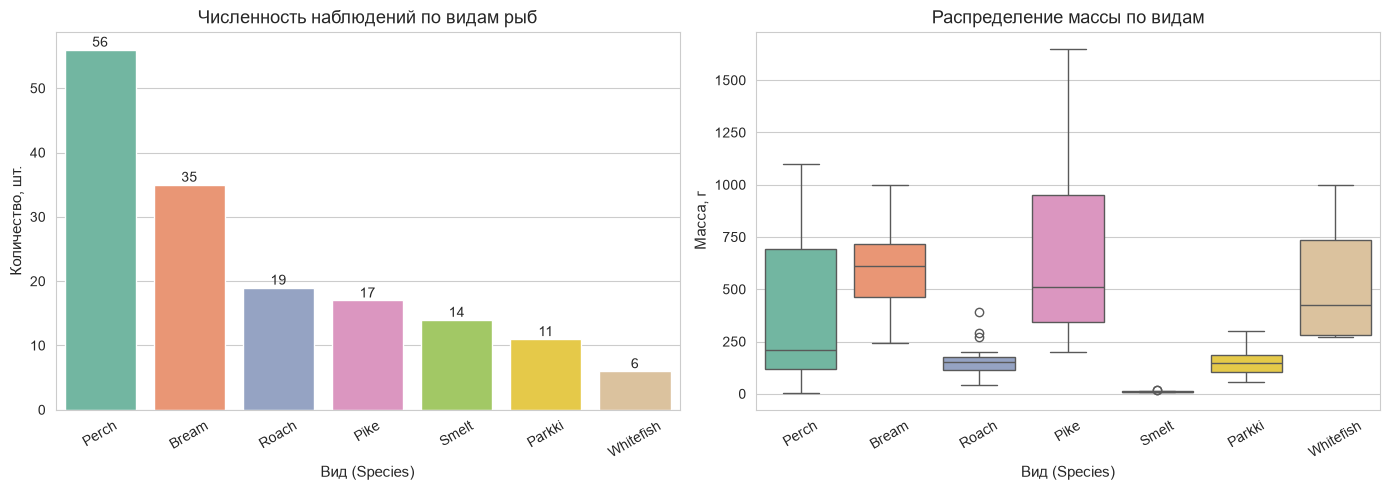

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Численность
order = df['Species'].value_counts().index
sns.countplot(data=df, x='Species', ax=axes[0], palette='Set2', order=order)
axes[0].set_title('Численность наблюдений по видам рыб')
axes[0].set_xlabel('Вид (Species)')
axes[0].set_ylabel('Количество, шт.')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Боксплот массы
sns.boxplot(data=df, x='Species', y='Weight', ax=axes[1],
            palette='Set2', order=order)
axes[1].set_title('Распределение массы по видам')
axes[1].set_xlabel('Вид (Species)')
axes[1].set_ylabel('Масса, г')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

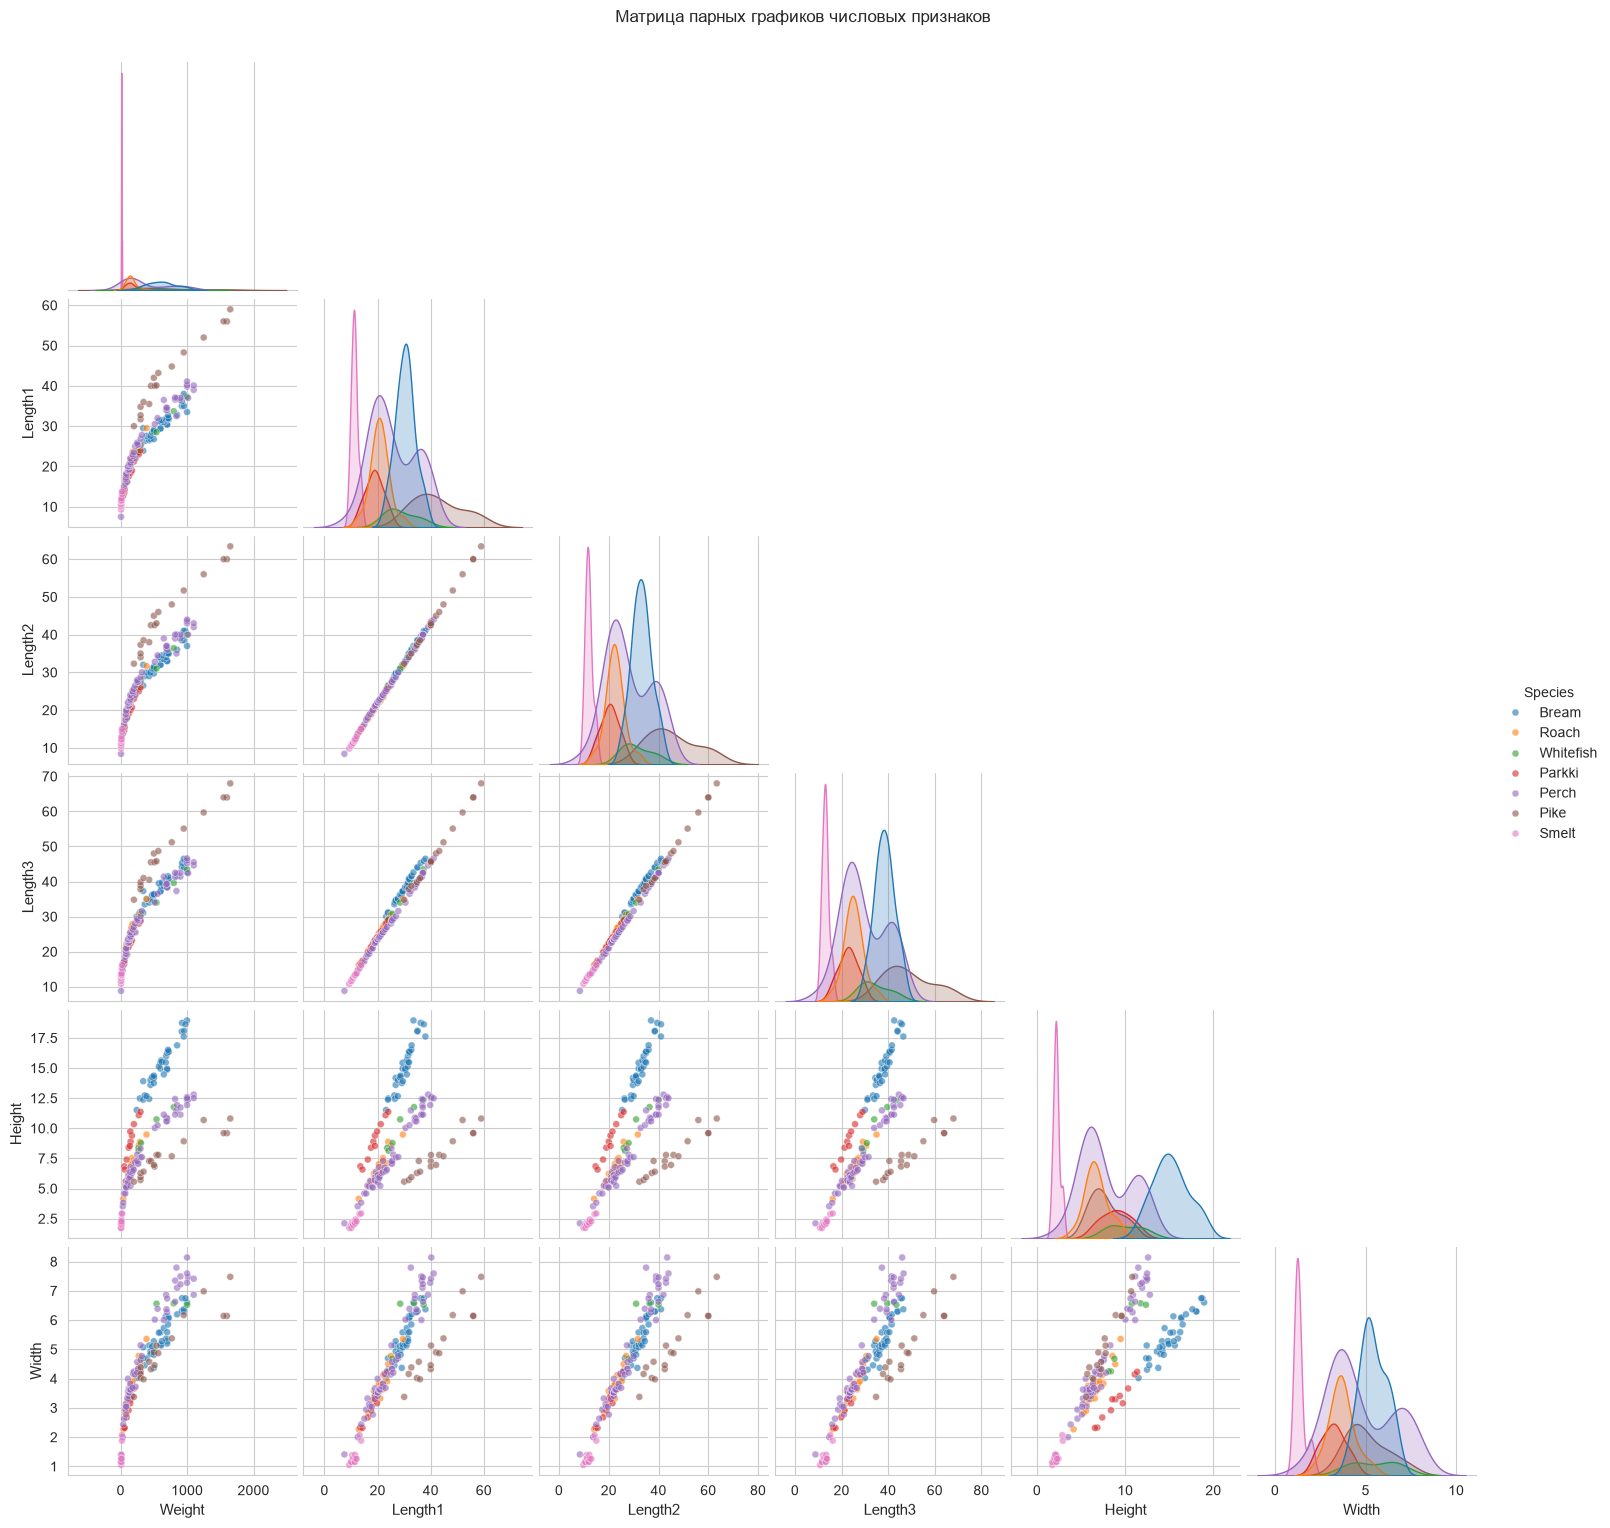

In [21]:
cols = ['Weight','Length1','Length2','Length3','Height','Width']

g = sns.pairplot(df[cols + ['Species']], hue='Species',
                 diag_kind='kde', corner=True,
                 plot_kws={'alpha':0.6, 's':25})
g.fig.suptitle('Матрица парных графиков числовых признаков', y=1.02)
plt.show()

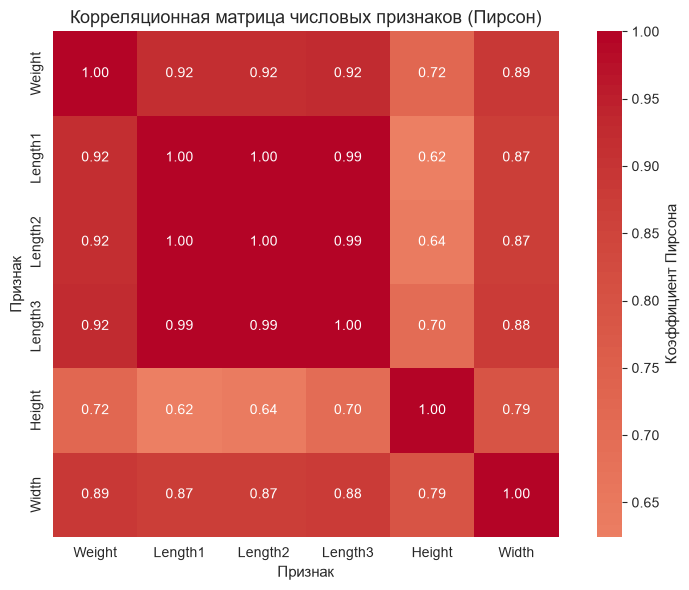

Spearman (Weight vs Length3): 0.966
Pearson  (Weight vs Length3): 0.923


In [22]:
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Коэффициент Пирсона'})
plt.title('Корреляционная матрица числовых признаков (Пирсон)')
plt.xlabel('Признак')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# Spearman для проверки нелинейных монотонных связей
corr_s = df[cols].corr(method='spearman')
print("Spearman (Weight vs Length3):", round(corr_s.loc['Weight','Length3'], 3))
print("Pearson  (Weight vs Length3):", round(corr.loc['Weight','Length3'], 3))

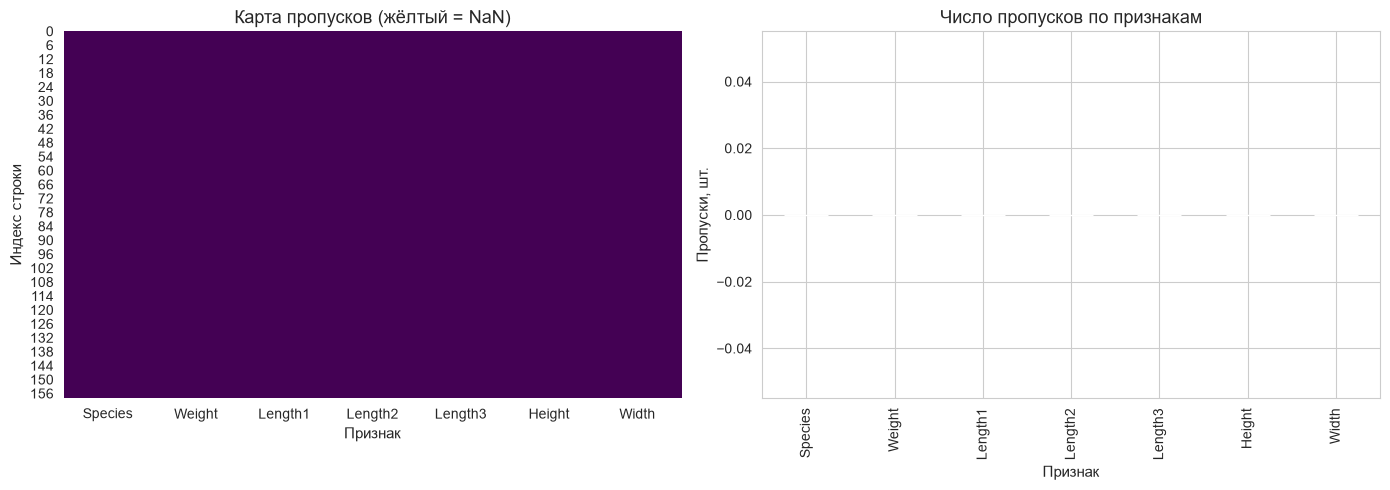

         Пропуски, шт.  Пропуски, %  Уникальных, шт.      Тип
Species              0          0.0                7      str
Weight               0          0.0              100  float64
Length1              0          0.0              116  float64
Length2              0          0.0               92  float64
Length3              0          0.0              124  float64
Height               0          0.0              153  float64
Width                0          0.0              151  float64

Полных дубликатов строк: 0
Отрицательных значений:   0
Нулевых значений:         0


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Карта пропусков
sns.heatmap(df.isna(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Карта пропусков (жёлтый = NaN)')
axes[0].set_xlabel('Признак')
axes[0].set_ylabel('Индекс строки')

# Столбиковая диаграмма пропусков
df.isna().sum().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Число пропусков по признакам')
axes[1].set_xlabel('Признак')
axes[1].set_ylabel('Пропуски, шт.')

plt.tight_layout()
plt.show()

# Таблица качества данных
quality = pd.DataFrame({
    'Пропуски, шт.': df.isna().sum(),
    'Пропуски, %':  (df.isna().mean()*100).round(2),
    'Уникальных, шт.': df.nunique(),
    'Тип': df.dtypes.astype(str)
})
print(quality)

print("\nПолных дубликатов строк:", df.duplicated().sum())
print("Отрицательных значений:  ", int((df[cols] < 0).sum().sum()))
print("Нулевых значений:        ", int((df[cols] == 0).sum().sum()))

In [31]:
def outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lo) | (series > hi), (lo, hi)

def outliers_mad(series, threshold=3.5):
    med = series.median()
    mad = (series - med).abs().median()
    z = 0.6745 * (series - med) / mad
    return z.abs() > threshold, z

mask_iqr, (lo_w, hi_w) = outliers_iqr(df['Weight'])
mask_mad, z_mad = outliers_mad(df['Weight'])

print(f"IQR-границы Weight: [{lo_w:.1f}, {hi_w:.1f}]")
print(f"Количество выбросов по IQR: {mask_iqr.sum()}")
print(f"Количество выбросов по MAD: {mask_mad.sum()}")

report = pd.DataFrame({
    'index': df.index,
    'Weight': df['Weight'].values,
    'IQR_out': mask_iqr.values,
    'MAD_z': z_mad.round(2).values,
    'MAD_out': mask_mad.values
})
print("\nПодозрительные строки:")
print(report[report['IQR_out'] | report['MAD_out']])

IQR-границы Weight: [-671.9, 1443.1]
Количество выбросов по IQR: 3
Количество выбросов по MAD: 3

Подозрительные строки:
     index  Weight  IQR_out  MAD_z  MAD_out
141    141  1600.0     True   4.19     True
142    142  1550.0     True   4.04     True
143    143  1650.0     True   4.35     True


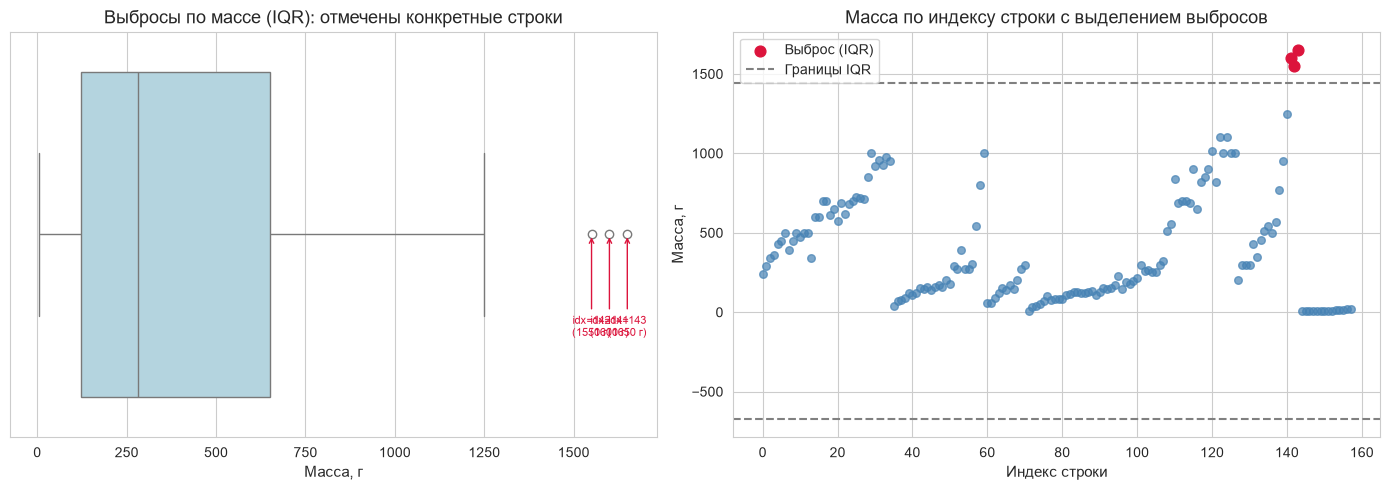

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Боксплот
sns.boxplot(x=df['Weight'], ax=axes[0], color='lightblue')
axes[0].set_title('Выбросы по массе (IQR): отмечены конкретные строки')
axes[0].set_xlabel('Масса, г')
axes[0].set_ylabel('')

for _, row in report[report['IQR_out']].iterrows():
    axes[0].annotate(f"idx={int(row['index'])}\n({row['Weight']:.0f} г)",
                     xy=(row['Weight'], 0),
                     xytext=(row['Weight'], 0.25),
                     ha='center', fontsize=8, color='crimson',
                     arrowprops=dict(arrowstyle='->', color='crimson'))

# Scatter по индексу
axes[1].scatter(df.index, df['Weight'], c='steelblue', alpha=0.7, s=30)
axes[1].scatter(report.loc[mask_iqr.values, 'index'],
                report.loc[mask_iqr.values, 'Weight'],
                c='crimson', s=60, label='Выброс (IQR)')
axes[1].axhline(lo_w, color='gray', ls='--', label=f'Границы IQR')
axes[1].axhline(hi_w, color='gray', ls='--')
axes[1].set_title('Масса по индексу строки с выделением выбросов')
axes[1].set_xlabel('Индекс строки')
axes[1].set_ylabel('Масса, г')
axes[1].legend()

plt.tight_layout()
plt.show()

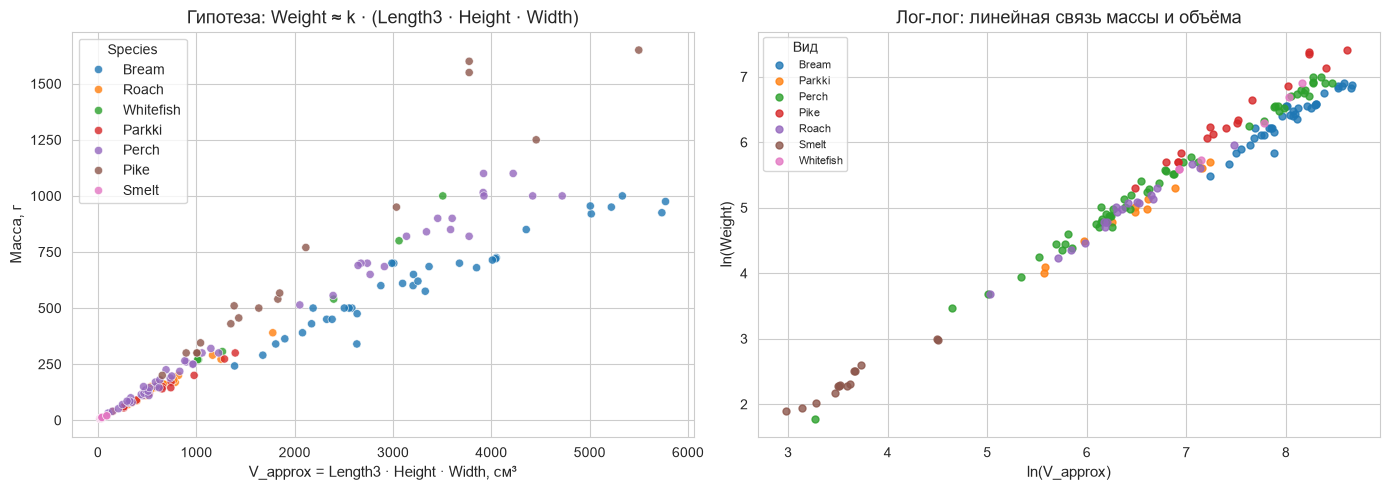

Pearson r (log-log): 0.991
Spearman r:          0.983


In [26]:
# Физическая гипотеза: масса ∝ объёму тела.
# Новый признак не использует целевую переменную Weight!
df['V_approx'] = df['Length3'] * df['Height'] * df['Width']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Общая зависимость
sns.scatterplot(data=df, x='V_approx', y='Weight', hue='Species',
                ax=axes[0], alpha=0.8, s=35)
axes[0].set_title('Гипотеза: Weight ≈ k · (Length3 · Height · Width)')
axes[0].set_xlabel('V_approx = Length3 · Height · Width, см³')
axes[0].set_ylabel('Масса, г')

# Лог-лог по видам
for sp, g in df.groupby('Species'):
    axes[1].scatter(np.log(g['V_approx']), np.log(g['Weight']),
                    label=sp, alpha=0.8, s=25)
axes[1].set_title('Лог-лог: линейная связь массы и объёма')
axes[1].set_xlabel('ln(V_approx)')
axes[1].set_ylabel('ln(Weight)')
axes[1].legend(fontsize=8, title='Вид')

plt.tight_layout()
plt.show()

r_log = np.corrcoef(np.log(df['V_approx']), np.log(df['Weight']))[0, 1]
r_sp  = stats.spearmanr(df['V_approx'], df['Weight']).correlation
print(f"Pearson r (log-log): {r_log:.3f}")
print(f"Spearman r:          {r_sp:.3f}")

In [ ]:
rows = []
for col in ['Weight','Length1','Length2','Length3','Height','Width']:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    med = s.median()
    mad = (s - med).abs().median()
    z = 0.6745 * (s - med) / mad
    rows.append({
        'Признак': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Нижняя граница': round(lo, 2),
        'Верхняя граница': round(hi, 2),
        'Выбросов IQR, шт.': int(((s < lo) | (s > hi)).sum()),
        'MAD': round(mad, 3),
        'Выбросов MAD (|z|>3.5), шт.': int((z.abs() > 3.5).sum()),
    })

outliers_table = pd.DataFrame(rows)
outliers_table

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,"Выбросов IQR, шт.",MAD,"Выбросов MAD (|z|>3.5), шт."
0,Weight,121.25,650.00,528.75,-671.88,1443.12,3,212.000,3
1,Length1,19.15,32.70,13.55,-1.18,53.03,3,6.550,0
2,Length2,21.00,35.75,14.75,-1.12,57.88,3,7.400,0
3,Length3,23.20,39.68,16.48,-1.51,64.39,1,8.650,0
4,Height,5.94,12.37,6.43,-3.71,22.02,0,2.745,0
5,Width,3.40,5.59,2.19,0.12,8.87,0,1.002,0


In [28]:
# --- Гипотеза 1 (физическая) ---
# V_approx = L3 · H · W  ∝ Weight  — подтверждена в ячейке 10.
# Новый признак рассчитан без Weight → безопасен для модели.

# --- Гипотеза 2 (категориальная) ---
# Species не имеет естественного порядка → One-Hot Encoding.
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(df[['Species']])
print("Категории, известные кодировщику:", list(enc.categories_[0]))
print("Пример вектора:", enc.transform(df[['Species']].head(1)).ravel())

Категории, известные кодировщику: ['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']
Пример вектора: [1. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Стратифицированное разбиение 60/20/20 по видам
train, temp = train_test_split(df, test_size=0.4,
                               stratify=df['Species'],
                               random_state=RANDOM_STATE)
val, test = train_test_split(temp, test_size=0.5,
                             stratify=temp['Species'],
                             random_state=RANDOM_STATE)

print(f"Train: {len(train)} ({len(train)/len(df):.0%})")
print(f"Val:   {len(val)}   ({len(val)/len(df):.0%})")
print(f"Test:  {len(test)}  ({len(test)/len(df):.0%})")
print("\nРаспределение видов в train:")
print(train['Species'].value_counts())

Train: 94 (59%)
Val:   32   (20%)
Test:  32  (20%)

Распределение видов в train:
Species
Perch        33
Bream        21
Roach        11
Pike         10
Smelt         8
Parkki        7
Whitefish     4
Name: count, dtype: int64


In [33]:
# === Ячейка 5.1. Функции IQR и MAD ===
import numpy as np
import pandas as pd

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr, q1, q3, iqr

def mad_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    z = 0.6745 * (s - med) / mad if mad else pd.Series(0.0, index=s.index)
    return z, med, mad


# === Ячейка 5.2. Расчёт по всем числовым признакам ===
NUMERIC_COLS = ["Weight","Length1","Length2","Length3","Height","Width"]

rows, details = [], {}
for col in NUMERIC_COLS:
    s = df[col].astype(float)
    lo, hi, q1, q3, iqr = iqr_bounds(s)
    z, med, mad = mad_z(s)
    m_iqr = (s < lo) | (s > hi)
    m_mad = z.abs() > 3.5
    details[col] = pd.DataFrame({
        "index": s.index, "value": s.values,
        "IQR_out": m_iqr.values, "z_MAD": z.round(3).values, "MAD_out": m_mad.values})
    rows.append({
        "Признак": col, "Q1": round(q1,2), "Q3": round(q3,2), "IQR": round(iqr,2),
        "MAD": round(mad,3), "Границы IQR": f"[{lo:.2f}, {hi:.2f}]",
        "IQR-выбросов": int(m_iqr.sum()), "MAD-выбросов": int(m_mad.sum())})

summary = pd.DataFrame(rows).set_index("Признак")
display(summary)


# === Ячейка 5.3. Сравнение списков IQR vs MAD ===
comp = []
for col in NUMERIC_COLS:
    r = details[col]
    comp.append({
        "Признак": col,
        "Только IQR": r[r.IQR_out & ~r.MAD_out].index.tolist(),
        "Только MAD": r[~r.IQR_out & r.MAD_out].index.tolist(),
        "Оба":        r[r.IQR_out & r.MAD_out].index.tolist()})
display(pd.DataFrame(comp).set_index("Признак"))

suspicious = sorted(set().union(*[set(details[c][details[c].IQR_out | details[c].MAD_out].index)
                                  for c in NUMERIC_COLS]))
print(f"Уникальных подозрительных строк: {len(suspicious)} → {suspicious}")


# === Ячейка 5.4. Действия по аномалиям ===
actions = []
for idx in suspicious:
    w, l3 = float(df.at[idx,"Weight"]), float(df.at[idx,"Length3"])
    if w > 1000:   kind, act = "очень крупный",  "оставить + is_large"
    elif w < 50:   kind, act = "аномально лёгкий","оставить + is_small"
    elif l3 < 15:  kind, act = "короткая рыба",  "оставить + is_short"
    else:          kind, act = "умеренное",      "оставить"
    actions.append({"index": idx, "Species": df.at[idx,"Species"],
                    "Weight": w, "Length3": l3, "Тип": kind, "Действие": act})
display(pd.DataFrame(actions))


# === Ячейка 5.5. Флаги ===
df["is_short"] = (df["Length3"] < df["Length3"].quantile(0.05)).astype(int)
df["is_large"] = (df["Weight"] > df["Weight"].quantile(0.95)).astype(int)
df["is_small"] = (df["Weight"] < df["Weight"].quantile(0.05)).astype(int)

print("График выбросов построен на шаге 4 — здесь только числовой разбор IQR/MAD.")
print("ВЫВОД: выброс ≠ ошибка; крупные/лёгкие экземпляры оставлены и помечены флагами.")

,Q1,Q3,IQR,MAD,Границы IQR,IQR-выбросов,MAD-выбросов
Признак,,,,,,,
Weight,121.25,650.00,528.75,212.000,"[-671.88, 1443.12]",3,3
Length1,19.15,32.70,13.55,6.550,"[-1.18, 53.03]",3,0
Length2,21.00,35.75,14.75,7.400,"[-1.12, 57.88]",3,0
Length3,23.20,39.68,16.48,8.650,"[-1.51, 64.39]",1,0
Height,5.94,12.37,6.43,2.745,"[-3.71, 22.02]",0,0
Width,3.40,5.59,2.19,1.002,"[0.12, 8.87]",0,0


,Только IQR,Только MAD,Оба
Признак,,,
Weight,[],[],"[141, 142, 143]"
Length1,"[141, 142, 143]",[],[]
Length2,"[141, 142, 143]",[],[]
Length3,[143],[],[]
Height,[],[],[]
Width,[],[],[]


Уникальных подозрительных строк: 3 → [141, 142, 143]


,index,Species,Weight,Length3,Тип,Действие
0,141,Pike,1600.0,64.0,очень крупный,оставить + is_large
1,142,Pike,1550.0,64.0,очень крупный,оставить + is_large
2,143,Pike,1650.0,68.0,очень крупный,оставить + is_large


График выбросов построен на шаге 4 — здесь только числовой разбор IQR/MAD.
ВЫВОД: выброс ≠ ошибка; крупные/лёгкие экземпляры оставлены и помечены флагами.


In [34]:
# --- Гипотеза 2 ---
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(df[["Species"]])

print("Категории:", list(enc.categories_[0]))
print("Новый вид →", enc.transform(pd.DataFrame({"Species": ["UnknownFish"]})).ravel())

Категории: ['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']
Новый вид → [0. 0. 0. 0. 0. 0. 0.]


In [35]:
# --- Гипотеза 3 ---
corr = df[["Length1","Length2","Length3"]].corr()
display(corr)

X = df[["Length1","Length2","Length3"]].values
X = (X - X.mean(0)) / X.std(0)
vif = np.diag(np.linalg.inv(np.corrcoef(X, rowvar=False)))
for name, v in zip(["Length1","Length2","Length3"], vif):
    print(f"VIF {name}: {v:.1f}")

,Length1,Length2,Length3
Length1,1.000000,0.999516,0.992004
Length2,0.999516,1.000000,0.994083
Length3,0.992004,0.994083,1.000000


VIF Length1: 1331.6
VIF Length2: 1797.6
VIF Length3: 109.2


In [36]:
# ============================================================
# ШАГ 7. РАЗБИЕНИЕ И ПРОВЕРКА УТЕЧЕК
# ============================================================
from sklearn.model_selection import train_test_split

# --- 7.1 Разбиение 60/20/20 (стратификация по Species) ---
train, temp = train_test_split(df, test_size=0.4,
                               stratify=df["Species"], random_state=42)
val, test = train_test_split(temp, test_size=0.5,
                             stratify=temp["Species"], random_state=42)
print(f"Train/Val/Test: {len(train)}/{len(val)}/{len(test)}")

# При появлении групп: GroupShuffleSplit(groups=df["FarmID"])

# --- 7.2 Проверка корректности ---
assert set(train.index).isdisjoint(val.index)
assert set(train.index).isdisjoint(test.index)
assert set(val.index).isdisjoint(test.index)
assert len(train)+len(val)+len(test) == len(df)
print("✅ Пересечений нет.")


# --- 7.3 Таблица каналов утечки ---
leakage = pd.DataFrame([
    ("Статистики всей таблицы", "Скейлер посчитан до split",
     "fit только на train, transform на val/test"),
    ("Повторные строки", "Один объект в train и test",
     "drop_duplicates до split"),
    ("Идентификатор", "Модель запоминает строку по номеру",
     "Удалить Id и индекс из признаков"),
    ("Постфактум-измерение", "Признак известен после события",
     "Проверить причинно-временную доступность"),
    ("Ручной подбор по test", "Гиперпараметры подобраны по test",
     "Подбор на val; test — один раз в конце"),
], columns=["Канал утечки", "Как проявляется", "Как предотвратить"])
display(leakage)


# --- 7.4 Ассерты утечки ---
assert np.allclose(df["Length3"]*df["Height"]*df["Width"], df["V_approx"])
assert "Weight" not in ["Species","Length1","Length2","Length3","Height","Width","V_approx"]
print("✅ Утечки из целевой переменной нет.")

Train/Val/Test: 94/32/32
✅ Пересечений нет.


,Канал утечки,Как проявляется,Как предотвратить
0,Статистики всей таблицы,Скейлер посчитан до split,"fit только на train, transform на val/test"
1,Повторные строки,Один объект в train и test,drop_duplicates до split
2,Идентификатор,Модель запоминает строку по номеру,Удалить Id и индекс из признаков
3,Постфактум-измерение,Признак известен после события,Проверить причинно-временную доступность
4,Ручной подбор по test,Гиперпараметры подобраны по test,Подбор на val; test — один раз в конце


✅ Утечки из целевой переменной нет.
